# Milan - Acoustic Classification (Zonizzazione Acustica) 2025

Downloads the official acoustic classification of the Municipality of Milan from the
city ArcGIS REST server (approved with D.C.C. n.29 del 14/04/2025), enriches each zone
with the legal dB limits from D.P.C.M. 14/11/1997, exports the enriched GeoJSON to
`../layers/milan_acoustic_classification_enriched.geojson`, and explores the data.

| CLASSE_ACU | Zone description | db_diurno (06-22) | db_notturno (22-06) |
|---|---|---|---|
| 1 | Aree particolarmente protette | 50 | 40 |
| 2 | Aree prevalentemente residenziali | 55 | 45 |
| 3 | Aree di tipo misto | 60 | 50 |
| 4 | Aree di intensa attivita umana | 65 | 55 |
| 5 | Aree prevalentemente industriali | 70 | 60 |
| 6 | Aree esclusivamente industriali | 70 | 70 |

In [1]:
import os
import time
import requests
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

## Task 1 - Fetch the data (paginated ArcGIS REST query)

The server caps each request, so we page through the layer with `resultOffset` /
`resultRecordCount` until an empty feature list comes back. If the enriched GeoJSON
already exists in `../layers/` the download is skipped.

In [2]:
URL = ('https://gisportal.comune.milano.it/server/rest/services/'
       'D_Verde_ambiente/Classificazione_Acustica_2025_Tavola/MapServer/5/query')
PAGE_SIZE = 1000

_layers_dir = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'layers')
ENRICHED_PATH = os.path.join(_layers_dir, 'milan_acoustic_classification_enriched.geojson')

if os.path.exists(ENRICHED_PATH):
    print('Enriched GeoJSON already exists - loading from cache:')
    print(' ', ENRICHED_PATH)
    acoustic = gpd.read_file(ENRICHED_PATH)
else:
    all_features = []
    offset = 0
    while True:
        params = {
            'where': '1=1',
            'outFields': '*',
            'f': 'geojson',
            'resultOffset': offset,
            'resultRecordCount': PAGE_SIZE,
        }
        for attempt in range(3):
            try:
                r = requests.get(URL, params=params, timeout=120)
                r.raise_for_status()
                data = r.json()
                break
            except Exception as e:
                print(f'  attempt {attempt + 1} failed ({e}), retrying in 5 s...')
                time.sleep(5)
        else:
            raise RuntimeError('Failed to fetch page after 3 attempts')

        feats = data.get('features', [])
        if not feats:
            break
        all_features.extend(feats)
        print(f'Fetched {len(feats):5d} features (total {len(all_features)})')
        offset += len(feats)

    print(f'Total features downloaded: {len(all_features)}')
    acoustic = gpd.GeoDataFrame.from_features(all_features, crs='EPSG:4326')

print('CRS:', acoustic.crs)
print('Shape:', acoustic.shape)
print('Columns:', acoustic.columns.tolist())

Fetched  1000 features (total 1000)


Fetched  1000 features (total 2000)


Fetched  1000 features (total 3000)


Fetched  1000 features (total 4000)


Fetched  1000 features (total 5000)


...

Fetched  1000 features (total 7000)


Fetched  1000 features (total 8000)


Fetched   828 features (total 8828)


Total features downloaded: 8828


CRS: EPSG:4326
Shape: (8828, 7)
Columns: ['geometry', 'OBJECTID', 'ID_CODE', 'CLASSE_ACU', 'NOTE', 'Shape_Length', 'Shape_Area']


In [3]:
print(acoustic['CLASSE_ACU'].value_counts(dropna=False).sort_index())
acoustic.head()

CLASSE_ACU
1      13
2     421
3    2397
4    5781
5     215
6       1
Name: count, dtype: int64


,geometry,OBJECTID,ID_CODE,CLASSE_ACU,NOTE,Shape_Length,Shape_Area
0,"POLYGON ((9.15261 45.43026, 9.15261 45.43026, ...",1,2604,1,,276.883353,4495.471904
1,"POLYGON ((9.1564 45.43066, 9.15639 45.43066, 9...",2,2634,1,,280.228347,4218.303349
2,"POLYGON ((9.15523 45.43101, 9.15478 45.43119, ...",3,2627,1,,356.630669,7179.386745
3,"POLYGON ((9.21913 45.43256, 9.21913 45.43256, ...",4,7051,1,,974.854714,59361.578049
4,"POLYGON ((9.08656 45.46437, 9.08657 45.46438, ...",5,271,1,,277.560684,4790.448245


## Task 2 - Enrich with decibel limits (D.P.C.M. 14/11/1997)

In [4]:
db_diurno_map = {1: 50, 2: 55, 3: 60, 4: 65, 5: 70, 6: 70}
db_notturno_map = {1: 40, 2: 45, 3: 50, 4: 55, 5: 60, 6: 70}

acoustic['CLASSE_ACU'] = acoustic['CLASSE_ACU'].astype(int)
acoustic['db_diurno'] = acoustic['CLASSE_ACU'].map(db_diurno_map)
acoustic['db_notturno'] = acoustic['CLASSE_ACU'].map(db_notturno_map)

assert acoustic['db_diurno'].notna().all(), 'Unmapped CLASSE_ACU values found'
assert acoustic['db_notturno'].notna().all(), 'Unmapped CLASSE_ACU values found'

acoustic[['CLASSE_ACU', 'db_diurno', 'db_notturno']].drop_duplicates().sort_values('CLASSE_ACU')

,CLASSE_ACU,db_diurno,db_notturno
0,1,50,40
13,2,55,45
143,3,60,50
512,4,65,55
3956,5,70,60
5277,6,70,70


## Task 3 - Export the enriched GeoJSON

In [5]:
if not os.path.exists(ENRICHED_PATH):
    acoustic.to_file(ENRICHED_PATH, driver='GeoJSON')
    print('Exported:', ENRICHED_PATH)
else:
    print('Already on disk:', ENRICHED_PATH)

C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


Exported: C:\Users\giofo\Desktop\ARCHIVIO\MASTERS\MACAD\2_MACAD\0_MACAD DRIVE\AIA\DATA ENCODING -- SUBMISSIONS\ML-Noise-Prediction\deployment\Milan\layers\milan_acoustic_classification_enriched.geojson


## Explore - reproject to metric CRS (EPSG:32632) for mapping

In [6]:
acoustic_m = acoustic.to_crs('EPSG:32632')
print('CRS:', acoustic_m.crs)
acoustic_m[['CLASSE_ACU', 'db_diurno', 'db_notturno']].describe()

CRS: EPSG:32632


,CLASSE_ACU,db_diurno,db_notturno
count,8828.000000,8828.000000,8828.000000
mean,3.653262,63.265745,53.266878
std,0.616568,3.081142,3.085453
min,1.000000,50.000000,40.000000
25%,3.000000,60.000000,50.000000
50%,4.000000,65.000000,55.000000
75%,4.000000,65.000000,55.000000
max,6.000000,70.000000,70.000000


## Acoustic class map

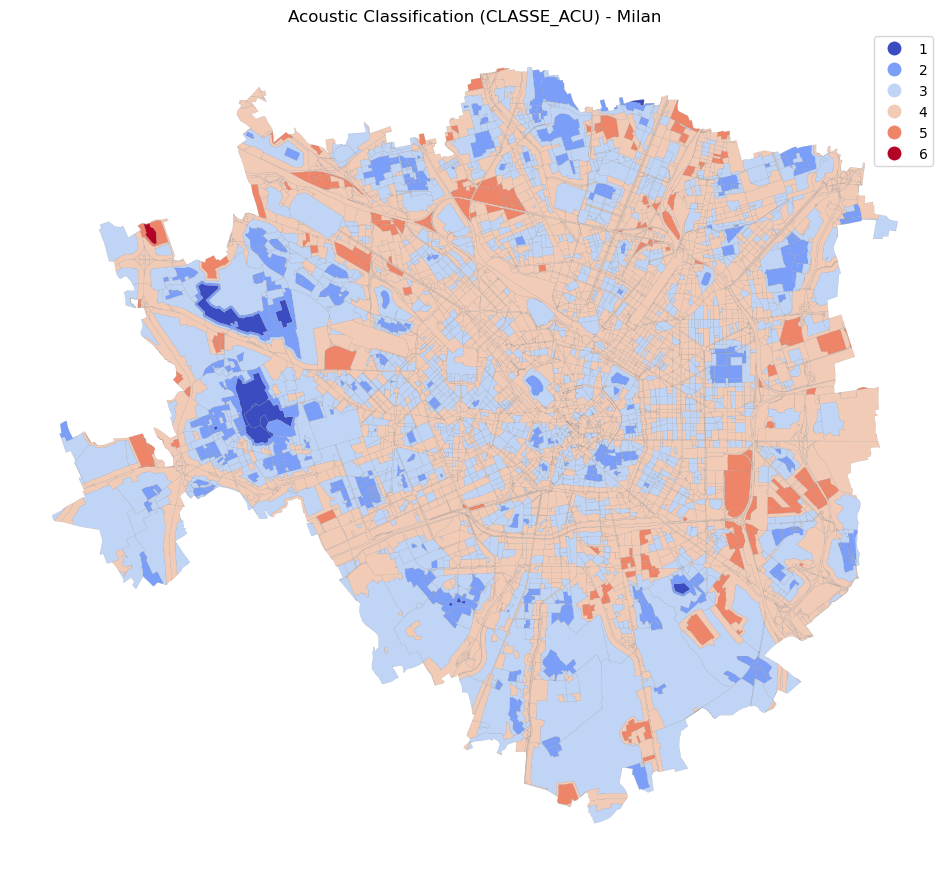

In [7]:
acoustic_m['classe_str'] = acoustic_m['CLASSE_ACU'].astype(str)
ax = acoustic_m.plot(column='classe_str', cmap='coolwarm', categorical=True,
                     legend=True, figsize=(12, 12), linewidth=0.1, edgecolor='grey')
ax.set_title('Acoustic Classification (CLASSE_ACU) - Milan')
ax.set_axis_off()

## Diurnal and nocturnal dB limit maps

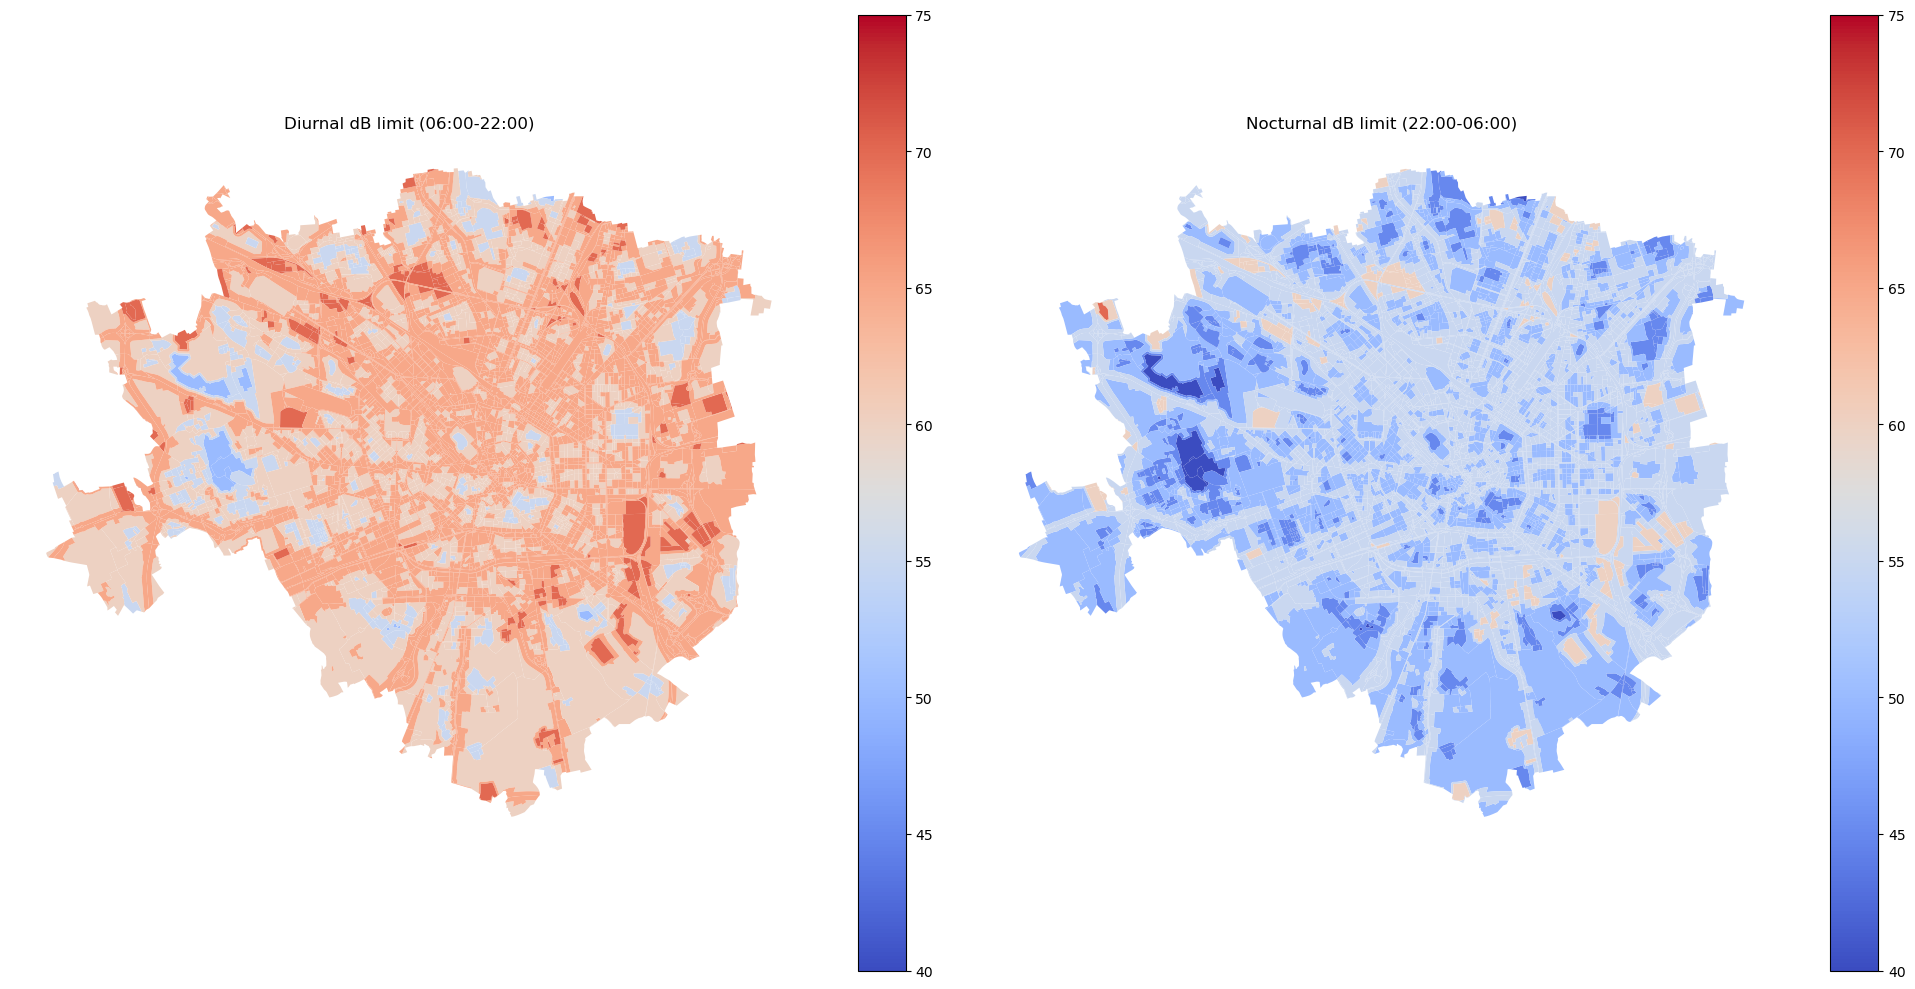

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
acoustic_m.plot(column='db_diurno', cmap='coolwarm', legend=True, ax=axes[0],
                vmin=40, vmax=75, linewidth=0)
axes[0].set_title('Diurnal dB limit (06:00-22:00)')
axes[0].set_axis_off()
acoustic_m.plot(column='db_notturno', cmap='coolwarm', legend=True, ax=axes[1],
                vmin=40, vmax=75, linewidth=0)
axes[1].set_title('Nocturnal dB limit (22:00-06:00)')
axes[1].set_axis_off()
plt.tight_layout()
plt.show()

## Zone count and area by class

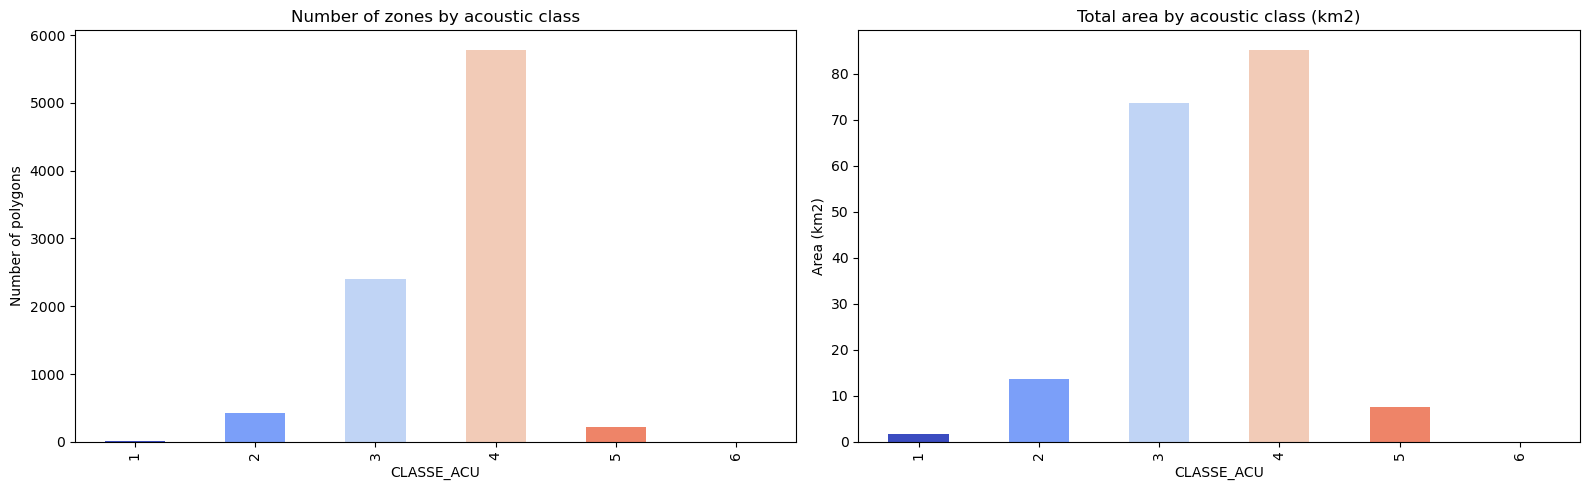

In [9]:
counts = acoustic_m['CLASSE_ACU'].value_counts().sort_index()
areas = acoustic_m.geometry.area.groupby(acoustic_m['CLASSE_ACU']).sum() / 1e6

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
counts.plot(kind='bar', ax=axes[0], color=plt.cm.coolwarm([0.0, 0.2, 0.4, 0.6, 0.8, 1.0]))
axes[0].set_title('Number of zones by acoustic class')
axes[0].set_xlabel('CLASSE_ACU')
axes[0].set_ylabel('Number of polygons')
areas.plot(kind='bar', ax=axes[1], color=plt.cm.coolwarm([0.0, 0.2, 0.4, 0.6, 0.8, 1.0]))
axes[1].set_title('Total area by acoustic class (km2)')
axes[1].set_xlabel('CLASSE_ACU')
axes[1].set_ylabel('Area (km2)')
plt.tight_layout()
plt.show()

## Summary statistics

In [10]:
total_area = acoustic_m.geometry.area.sum() / 1e6
print(f'Total zones: {len(acoustic_m)}')
print(f'Total classified area: {total_area:.1f} km2')
print(f'Mean diurnal limit (area-weighted): '
      f'{(acoustic_m["db_diurno"] * acoustic_m.geometry.area).sum() / acoustic_m.geometry.area.sum():.1f} dB')
print(f'Mean nocturnal limit (area-weighted): '
      f'{(acoustic_m["db_notturno"] * acoustic_m.geometry.area).sum() / acoustic_m.geometry.area.sum():.1f} dB')

Total zones: 8828
Total classified area: 181.8 km2
Mean diurnal limit (area-weighted): 62.3 dB
Mean nocturnal limit (area-weighted): 52.3 dB
